<a href="https://colab.research.google.com/github/israakadhem0-coder/coronavirus/blob/main/bioactivity_prediction_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **QSAR Model Building of NRF2 **



# Read in data

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/CORONA_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [6]:
X = df.drop(['pIC50'], axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
68,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
69,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
70,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [7]:
Y = df.iloc[:,-1]
Y

,pIC50
0,4.869666
1,4.882397
2,6.008774
3,6.022276
4,4.950782
...,...
67,4.950000
68,4.958607
69,5.000000
70,5.000000


# Remove low variance features

In [8]:
from sklearn.feature_selection import VarianceThreshold

def remove_low_variance(input_data, threshold=0.1):
    selection = VarianceThreshold(threshold)
    selection.fit(input_data)
    return input_data[input_data.columns[selection.get_support(indices=True)]]

X = remove_low_variance(X, threshold=0.1)
X

,PubchemFP2,PubchemFP12,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,PubchemFP24,PubchemFP33,PubchemFP34,...,PubchemFP708,PubchemFP709,PubchemFP710,PubchemFP712,PubchemFP716,PubchemFP729,PubchemFP758,PubchemFP779,PubchemFP792,PubchemFP821
0,0,1,0,0,1,1,0,0,0,0,...,1,1,1,0,0,0,1,0,0,1
1,0,1,0,0,1,0,0,0,1,0,...,1,1,1,0,0,0,1,0,0,1
2,0,1,0,0,1,0,0,0,1,0,...,1,1,1,0,0,0,1,0,0,1
3,0,1,0,0,1,0,0,0,1,0,...,1,1,1,0,0,0,1,0,0,1
4,0,1,0,0,1,0,0,0,1,0,...,1,1,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,1,1,1,1,0,0,0,0,1,1,...,1,1,1,1,0,1,0,0,1,0
68,1,1,1,1,0,0,0,0,1,1,...,1,1,1,1,0,1,0,0,1,0
69,0,1,1,1,0,0,1,1,1,1,...,0,0,0,0,0,1,0,0,1,0
70,0,1,1,1,0,0,1,1,1,1,...,0,0,0,0,0,1,0,0,1,0


In [9]:
X.to_csv('descriptor_list.csv', index = False)

In [ ]:
# In the app, use the following to get this same descriptor list
# of 218 variables from the initial set of 881 variables
# Xlist = list(pd.read_csv('descriptor_list.csv').columns)
# X[Xlist]

# Random Forest Regression Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X, Y)
r2 = model.score(X, Y)
r2

0.9189165794478408

## Model Prediction

In [12]:
Y_pred = model.predict(X)
Y_pred

array([4.77111729, 5.37145999, 5.37145999, 5.37145999, 5.09448114,
       5.37145999, 4.93539977, 4.83464697, 4.33842485, 4.25918883,
       4.32038438, 5.76454153, 4.97634316, 4.61221762, 4.61221762,
       4.29663196, 4.55056089, 3.59987578, 3.59987578, 3.64216411,
       3.64216411, 3.73924029, 3.73924029, 3.96971087, 3.96971087,
       4.22616947, 4.22616947, 4.28890343, 4.28890343, 4.38648468,
       4.38648468, 4.81701775, 4.81701775, 4.82532609, 4.82532609,
       4.90979264, 4.90979264, 3.07013865, 3.07013865, 3.40393277,
       3.40393277, 3.49925765, 3.49925765, 3.49678326, 3.49678326,
       3.5495368 , 3.5495368 , 3.66458182, 3.66458182, 3.80851517,
       3.80851517, 3.6851953 , 3.6851953 , 3.82607888, 3.82607888,
       3.76601722, 3.76601722, 4.22357625, 4.22357625, 4.37746863,
       4.37746863, 4.41380821, 4.41380821, 4.81701775, 4.81701775,
       4.8418869 , 4.8418869 , 4.94195348, 4.94195348, 4.97235302,
       4.97235302, 5.26498572])

## Model Performance

In [13]:
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y, Y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y, Y_pred))

Mean squared error (MSE): 0.04
Coefficient of determination (R^2): 0.92


# Data Visualization (Experimental vs Predicted pIC50 for Training Data)

In [14]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0, 'Experimental pIC50')

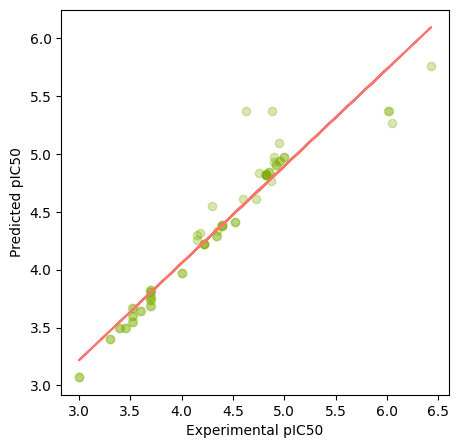

In [15]:
plt.figure(figsize=(5,5))
plt.scatter(x=Y, y=Y_pred, c="#7CAE00", alpha=0.3)

# Add trendline
# https://stackoverflow.com/questions/26447191/how-to-add-trendline-in-python-matplotlib-dot-scatter-graphs
z = np.polyfit(Y, Y_pred, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.ylabel('Predicted pIC50')
plt.xlabel('Experimental pIC50')

# Save Model as Pickle Object

In [16]:
import pickle

In [17]:
pickle.dump(model, open('acetylcholinesterase_model.pkl', 'wb'))